In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

import os
import sys
os.chdir("..")

df_listings = pd.read_csv('data/combined_csvs/listings_property_vals.csv')
df_future = pd.read_csv('data/combined_csvs/future_rates.csv')
df_past = pd.read_csv('data/combined_csvs/past_rates.csv')
df_reviews = pd.read_csv('data/combined_csvs/reviews.csv')

In [2]:
len(df_listings)

2882

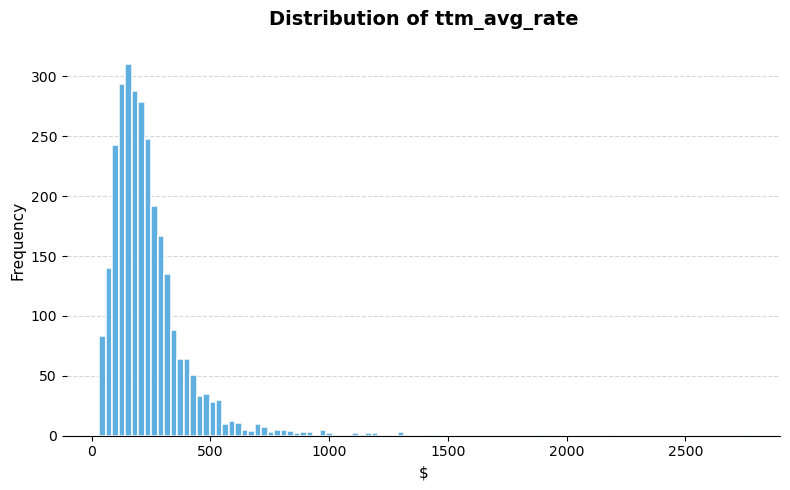

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    df_listings["ttm_avg_rate"],
    bins=100,
    color="#4EA8DE",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.9,
)

ax.set_title("Distribution of ttm_avg_rate", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("$", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

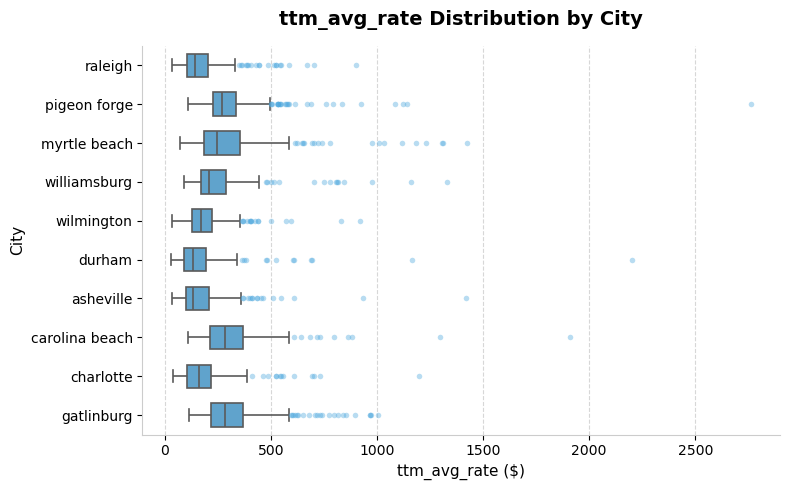

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

# flierprops styles the outlier points to keep them clean and subtle
sns.boxplot(
    data=df_listings,
    x="ttm_avg_rate",
    y="city",
    ax=ax,
    color="#4EA8DE",
    width=0.6,
    linewidth=1.2,
    flierprops={
        "marker": "o",
        "markersize": 4,
        "markerfacecolor": "#4EA8DE",
        "markeredgecolor": "none",
        "alpha": 0.4,
    },
)

ax.set_title(
    "ttm_avg_rate Distribution by City", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("ttm_avg_rate ($)", fontsize=11)
ax.set_ylabel("City", fontsize=11)

ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

plt.tight_layout()
plt.show()

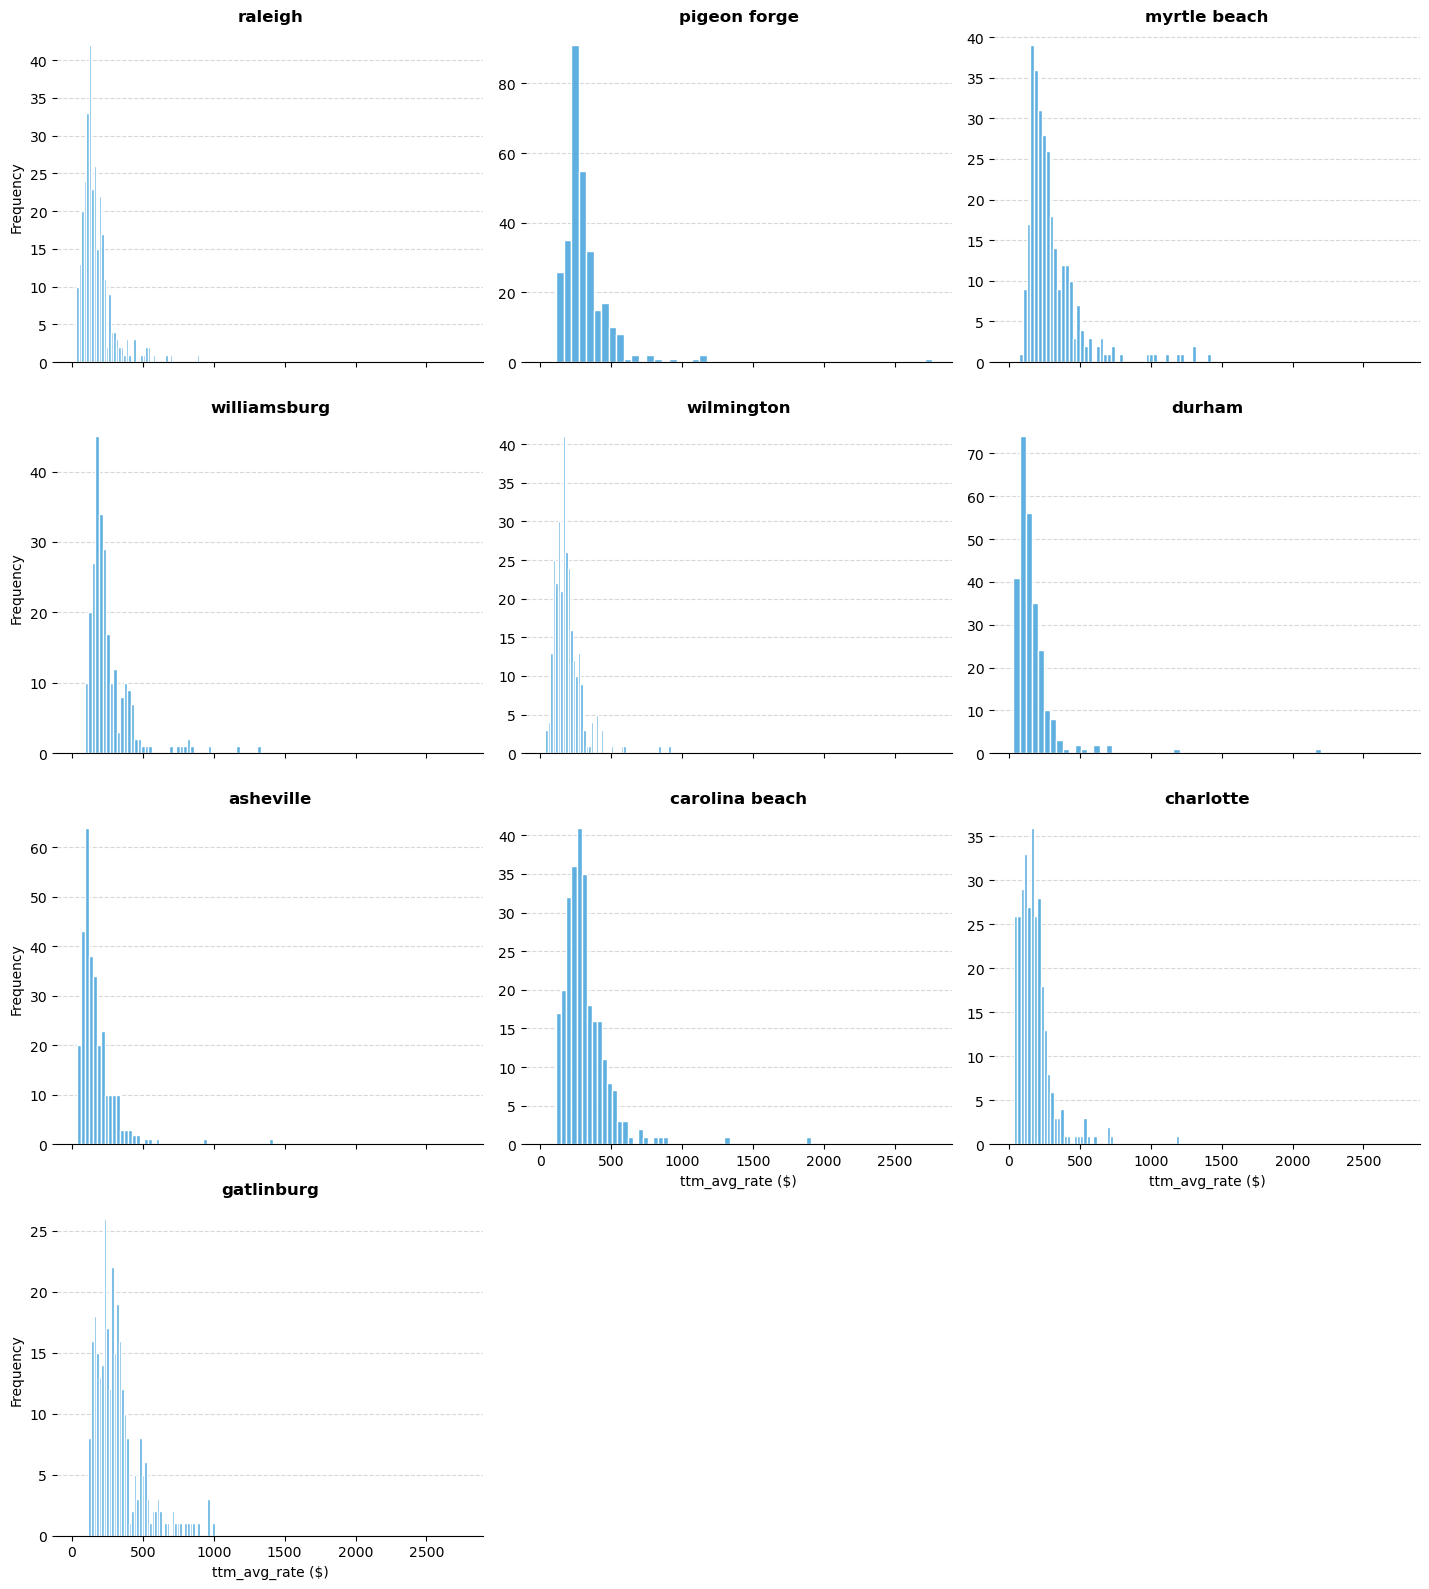

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# This automatically creates a grid of plots based on the number of unique cities
g = sns.FacetGrid(
    df_listings, col="city", col_wrap=3, height=4, aspect=1.2, sharey=False
)

g.map_dataframe(
    sns.histplot,
    x="ttm_avg_rate",
    bins=50,
    color="#4EA8DE",
    edgecolor="white",
    linewidth=1,
    alpha=0.9,
)

g.set_titles(col_template="{col_name}", size=12, weight="bold")
g.set_axis_labels("ttm_avg_rate ($)", "Frequency")

for ax in g.axes.flat:
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

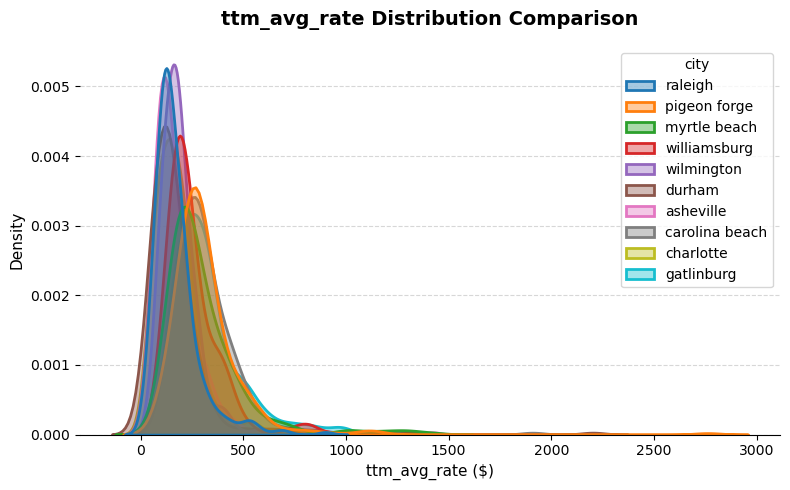

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(
    data=df_listings,
    x="ttm_avg_rate",
    hue="city",
    fill=True,
    common_norm=False,
    alpha=0.4,
    linewidth=2,
    ax=ax,
)

ax.set_title(
    "ttm_avg_rate Distribution Comparison", fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("ttm_avg_rate ($)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_42218/886128291.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


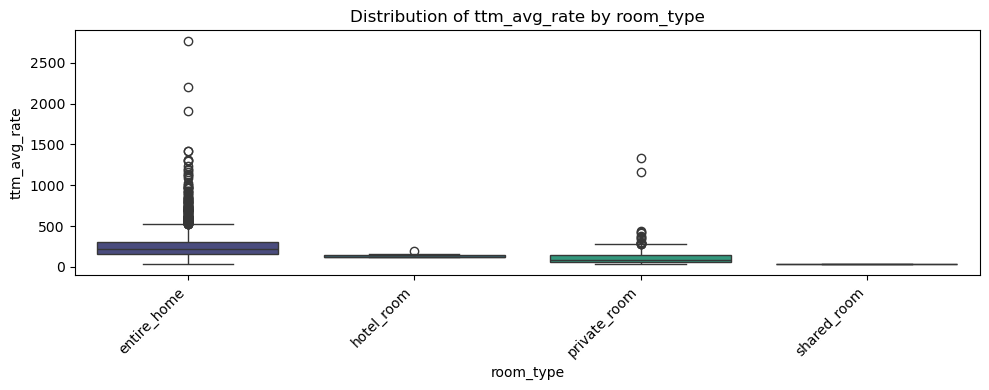

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_42218/886128291.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


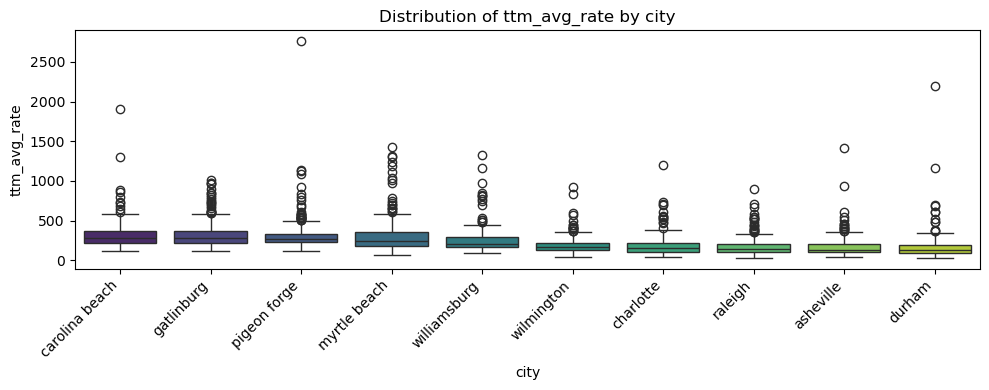

/var/folders/gm/dyt9t75x0kn2y9njgtrx0ddr0000gn/T/ipykernel_42218/886128291.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


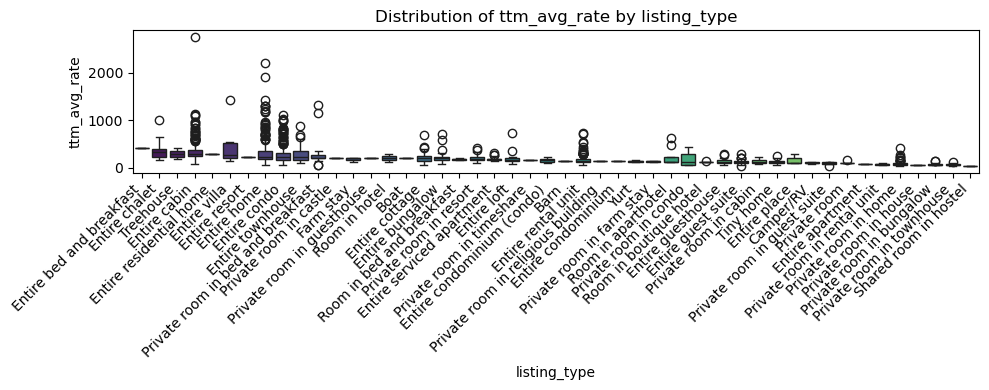

In [7]:
filtered_df = df_listings.loc[:, ~df_listings.columns.str.startswith("l90d_")]
numeric_df = filtered_df.select_dtypes(include=["number"])
target_metric = "ttm_avg_rate"
for col in ["room_type", "city", "listing_type"]:  
    plt.figure(figsize=(10, 4))
    
    # Sort categories by median yield for a cleaner plot
    order = filtered_df.groupby(col)[target_metric].median().sort_values(ascending=False).index
    
    sns.boxplot(
        data=filtered_df, 
        x=col, 
        y=target_metric, 
        order=order,
        palette="viridis"
    )
    plt.title(f"Distribution of {target_metric} by {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()